# Chapter 3: Network Architectures — PyTorch Code
# 第3章：ネットワークアーキテクチャ — PyTorchコード

This notebook accompanies Chapter 3. We will implement:
1. A CNN feature extractor to see how layers behave (§3.1)
2. A minimal Encoder-Decoder (§3.2)
3. A simplified FCN (§3.3)
4. A simplified U-Net with skip connections (§3.3)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.2.1+cu121
Using device: cuda


---
## 3.1 CNN Basics Refresher / CNNの基礎のおさらい

Let's visualise what happens to a feature map as it passes through CNN layers.
CNN層を通過するにつれて特徴マップがどう変化するかを可視化します。

In [2]:
# --- Helper: make a fake RGB image batch ---
# shape: (batch=1, channels=3, H=64, W=64)
torch.manual_seed(0)
fake_image = torch.randn(1, 3, 64, 64)
print("Input shape:", fake_image.shape)  # (N, C, H, W)

Input shape: torch.Size([1, 3, 64, 64])


In [3]:
# A simple two-block CNN encoder
# Each block: Conv2d → BatchNorm → ReLU → MaxPool (halves spatial size)
class SimpleCNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 3 → 16 channels
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 64×64 → 32×32
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16 → 32 channels
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 32×32 → 16×16
        )

    def forward(self, x):
        x1 = self.block1(x)   # early features
        x2 = self.block2(x1)  # deeper features
        return x1, x2

encoder = SimpleCNNEncoder()
with torch.no_grad():
    feat1, feat2 = encoder(fake_image)

print(f"After block 1 (early layers):  {feat1.shape}")  # (1, 16, 32, 32)
print(f"After block 2 (deeper layers): {feat2.shape}")  # (1, 32, 16, 16)
print()
print("Key observation: spatial size halved, channel count doubled — typical CNN behaviour.")
print("主な観察：空間サイズが半分になり、チャンネル数が倍になります — CNNの典型的な挙動です。")

After block 1 (early layers):  torch.Size([1, 16, 32, 32])
After block 2 (deeper layers): torch.Size([1, 32, 16, 16])

Key observation: spatial size halved, channel count doubled — typical CNN behaviour.
主な観察：空間サイズが半分になり、チャンネル数が倍になります — CNNの典型的な挙動です。


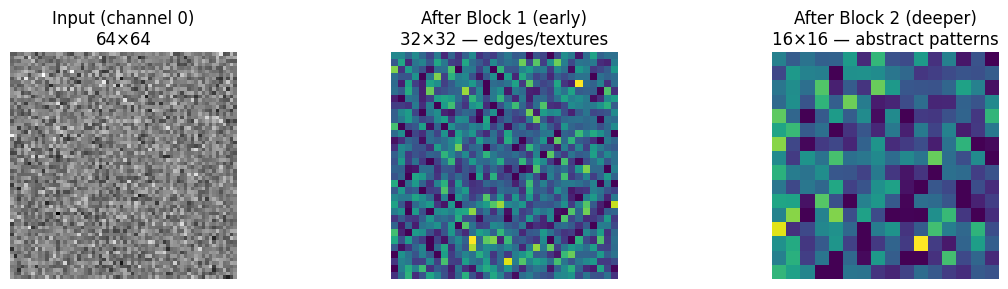

Saved as feature_maps.png


In [4]:
# Visualise a single feature map from each block
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].imshow(fake_image[0, 0].numpy(), cmap="gray")
axes[0].set_title("Input (channel 0)\n64×64")

axes[1].imshow(feat1[0, 0].detach().numpy(), cmap="viridis")
axes[1].set_title("After Block 1 (early)\n32×32 — edges/textures")

axes[2].imshow(feat2[0, 0].detach().numpy(), cmap="viridis")
axes[2].set_title("After Block 2 (deeper)\n16×16 — abstract patterns")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("feature_maps.png", dpi=100)
plt.show()
print("Saved as feature_maps.png")

---
## 3.2 The Encoder-Decoder Structure / エンコーダ・デコーダ構造

We extend the encoder above with a decoder that upsamples back to the original resolution.
上のエンコーダを拡張し、元の解像度に戻すデコーダを追加します。

In [5]:
class MinimalEncoderDecoder(nn.Module):
    """
    Minimal encoder-decoder for semantic segmentation.
    Input:  (N, 3, H, W)
    Output: (N, num_classes, H, W)
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # --- Encoder (downsampling) ---
        self.enc1 = self._conv_block(3,  16)   # 64 → 32
        self.enc2 = self._conv_block(16, 32)   # 32 → 16
        self.enc3 = self._conv_block(32, 64)   # 16 →  8

        # --- Decoder (upsampling) ---
        # nn.Upsample doubles the spatial size; bilinear is smooth
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            self._conv_block(64, 32, pool=False),  #  8 → 16
        )
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            self._conv_block(32, 16, pool=False),  # 16 → 32
        )
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            self._conv_block(16, 16, pool=False),  # 32 → 64
        )

        # Final 1×1 conv maps features → class scores
        self.head = nn.Conv2d(16, num_classes, kernel_size=1)

    @staticmethod
    def _conv_block(in_ch, out_ch, pool=True):
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encode
        x = self.enc1(x)  # (N,  16, H/2, W/2)
        x = self.enc2(x)  # (N,  32, H/4, W/4)
        x = self.enc3(x)  # (N,  64, H/8, W/8)  ← bottleneck

        # Decode
        x = self.up1(x)   # (N,  32, H/4, W/4)
        x = self.up2(x)   # (N,  16, H/2, W/2)
        x = self.up3(x)   # (N,  16,   H,   W)

        return self.head(x)  # (N, num_classes, H, W)


model_ed = MinimalEncoderDecoder(num_classes=10)
with torch.no_grad():
    out_ed = model_ed(fake_image)

print("Input  shape:", fake_image.shape)
print("Output shape:", out_ed.shape)
print("Input and output spatial size match:", fake_image.shape[2:] == out_ed.shape[2:])
total_params = sum(p.numel() for p in model_ed.parameters())
print(f"Total parameters: {total_params:,}")

Input  shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 10, 64, 64])
Input and output spatial size match: True
Total parameters: 49,514


---
## 3.3 Classic Milestones / 代表的な古典モデル

### Part A — Simplified FCN

The FCN idea: remove Dense layers from a standard CNN, keep everything convolutional, then upsample once at the end.

FCNのアイデア：標準CNNのDense層を削除し、すべてを畳み込みのみで構成し、最後に一度アップサンプリングします。

In [6]:
class SimplifiedFCN(nn.Module):
    """
    Inspired by Long et al. (2015).
    Replaces Fully Connected layers with 1×1 convolutions,
    then bilinearly upsamples to the original resolution.

    Long ら (2015) にインスパイアされた実装。
    全結合層を1×1畳み込みに置き換え、双線形補間で元の解像度に戻します。
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # Backbone: fully convolutional feature extractor
        self.features = nn.Sequential(
            self._conv_block(3,  64),   # H → H/2
            self._conv_block(64, 128),  # H/2 → H/4
            self._conv_block(128, 256), # H/4 → H/8
        )

        # "Dense layers" replaced by 1×1 convolutions
        self.classifier = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, kernel_size=1),
        )

    @staticmethod
    def _conv_block(in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        x = self.features(x)       # (N, 256, H/8, W/8)
        x = self.classifier(x)     # (N, num_classes, H/8, W/8)
        # Single bilinear upsample back to original size
        x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return x                   # (N, num_classes, H, W)


fcn = SimplifiedFCN(num_classes=10)
with torch.no_grad():
    out_fcn = fcn(fake_image)

print("FCN input shape: ", fake_image.shape)
print("FCN output shape:", out_fcn.shape)
print(f"FCN parameters: {sum(p.numel() for p in fcn.parameters()):,}")

FCN input shape:  torch.Size([1, 3, 64, 64])
FCN output shape: torch.Size([1, 10, 64, 64])
FCN parameters: 440,074


### Part B — Simplified U-Net with Skip Connections

U-Net's key idea: at each scale, concatenate the encoder feature map directly with the decoder feature map before upsampling. This restores fine spatial detail that the bottleneck lost.

U-Netの核心：各スケールで、アップサンプリング前にエンコーダの特徴マップをデコーダの特徴マップに直接連結します。これにより、ボトルネックで失われた細かい空間的詳細が復元されます。

In [7]:
class DoubleConv(nn.Module):
    """The standard U-Net building block: Conv → BN → ReLU → Conv → BN → ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SimpleUNet(nn.Module):
    """
    Simplified U-Net (3 encoder levels + bottleneck + 3 decoder levels).
    Illustrates the skip-connection mechanism from Ronneberger et al. (2015).

    簡略化されたU-Net（エンコーダ3段 + ボトルネック + デコーダ3段）。
    Ronneberger ら (2015) のスキップ結合機構を示します。
    """
    def __init__(self, in_channels=3, num_classes=10, features=(16, 32, 64)):
        super().__init__()

        # --- Encoder ---
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        # --- Bottleneck ---
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # --- Decoder ---
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        up_ch = features[-1] * 2
        for f in reversed(features):
            # Upsample halves channels; concatenation with skip doubles them again
            self.upconvs.append(
                nn.ConvTranspose2d(up_ch, f, kernel_size=2, stride=2)
            )
            self.decoders.append(DoubleConv(f * 2, f))  # f*2 because of concat
            up_ch = f

        # --- Final classification head ---
        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skips = []

        # Encode — save feature maps for skip connections
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)   # save before pooling
            x = pool(x)

        x = self.bottleneck(x)

        # Decode — concatenate with saved skip connections
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)

            # Handle odd input sizes: crop skip to match x if needed
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:],
                                  mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)  # <-- skip connection (concat)
            x = dec(x)

        return self.head(x)  # (N, num_classes, H, W)


unet = SimpleUNet(in_channels=3, num_classes=10)
with torch.no_grad():
    out_unet = unet(fake_image)

print("U-Net input shape: ", fake_image.shape)
print("U-Net output shape:", out_unet.shape)
print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}")

U-Net input shape:  torch.Size([1, 3, 64, 64])
U-Net output shape: torch.Size([1, 10, 64, 64])
U-Net parameters: 482,890


### Comparing all three architectures / 3つのアーキテクチャの比較

In [8]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

models = {
    "MinimalEncoderDecoder": model_ed,
    "SimplifiedFCN":         fcn,
    "SimpleUNet":            unet,
}

print(f"{'Model':<26} {'Params':>10}  {'Output shape'}")
print("-" * 60)
for name, m in models.items():
    with torch.no_grad():
        out = m(fake_image)
    print(f"{name:<26} {count_params(m):>10,}  {tuple(out.shape)}")

Model                          Params  Output shape
------------------------------------------------------------
MinimalEncoderDecoder          49,514  (1, 10, 64, 64)
SimplifiedFCN                 440,074  (1, 10, 64, 64)
SimpleUNet                    482,890  (1, 10, 64, 64)


### Training loop demo — one batch / トレーニングループのデモ（1バッチ）

A quick demonstration of how to compute cross-entropy loss on a segmentation output and run a backward pass.

セグメンテーション出力に対してクロスエントロピー損失を計算し、逆伝播を実行する方法の簡単なデモです。

In [9]:
NUM_CLASSES = 10
H, W = 64, 64

# Fake ground-truth segmentation mask: each pixel has a class index in [0, NUM_CLASSES)
# 偽の正解セグメンテーションマスク：各ピクセルに [0, NUM_CLASSES) のクラスインデックス
fake_mask = torch.randint(0, NUM_CLASSES, (1, H, W))  # (N, H, W) — no channel dim

model = SimpleUNet(num_classes=NUM_CLASSES)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()  # expects (N, C, H, W) logits and (N, H, W) targets

model.train()
for step in range(5):
    optimizer.zero_grad()
    logits = model(fake_image)          # (1, 10, 64, 64)
    loss = criterion(logits, fake_mask) # scalar
    loss.backward()
    optimizer.step()
    print(f"Step {step+1}/5 — loss: {loss.item():.4f}")

print("\nTraining loop works correctly. 学習ループが正常に動作しています。")

Step 1/5 — loss: 2.3576
Step 2/5 — loss: 2.2850
Step 3/5 — loss: 2.2366
Step 4/5 — loss: 2.1989
Step 5/5 — loss: 2.1669

Training loop works correctly. 学習ループが正常に動作しています。


### Visualising predictions / 予測の可視化

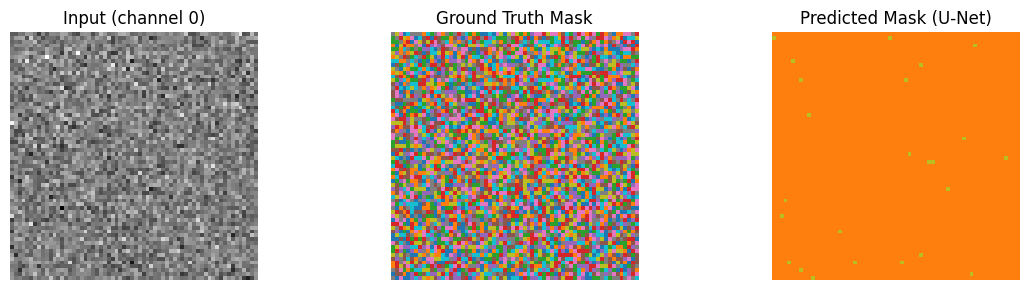

Saved as unet_prediction.png


In [10]:
model.eval()
with torch.no_grad():
    logits = model(fake_image)              # (1, 10, 64, 64)
    pred_mask = logits.argmax(dim=1)[0]     # (64, 64) — class with highest score per pixel

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].imshow(fake_image[0].permute(1, 2, 0).numpy()
               .clip(0, 1) if False else
               (fake_image[0, 0] - fake_image[0, 0].min()).numpy() /
               (fake_image[0, 0].max() - fake_image[0, 0].min()).numpy(),
               cmap="gray")
axes[0].set_title("Input (channel 0)")

axes[1].imshow(fake_mask[0].numpy(), cmap="tab10", vmin=0, vmax=NUM_CLASSES - 1)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(pred_mask.numpy(), cmap="tab10", vmin=0, vmax=NUM_CLASSES - 1)
axes[2].set_title("Predicted Mask (U-Net)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("unet_prediction.png", dpi=100)
plt.show()
print("Saved as unet_prediction.png")

---
## Summary / まとめ

| Concept | Key point | キーポイント |
|---|---|---|
| CNN layers | Shrink spatial size, grow channels | 空間サイズを縮小、チャンネルを拡大 |
| Encoder-Decoder | Compress → reconstruct at full res | 圧縮 → 元解像度に再構成 |
| FCN | Remove Dense layers, upsample once | Dense層を削除し、一度アップサンプリング |
| U-Net | Skip connections restore sharp edges | スキップ結合でシャープな境界を復元 |

### Next steps / 次のステップ
- Replace the fake data with a real dataset (e.g., Pascal VOC, Cityscapes) and train for more epochs.  
  偽データを実際のデータセット（例：Pascal VOC、Cityscapes）に置き換え、より多くのエポックで学習してみましょう。
- Compute mean IoU on a validation split to measure segmentation quality.  
  検証データに対してmean IoUを計算し、セグメンテーション品質を測定しましょう。